In [36]:
from psana import *
import math
from scipy import signal
import matplotlib.pyplot as plt
from array import array
import sys
import numpy as np


##  Grabs Wave8 waveform data from XTC, and calculates peak amplitude.  Should
##  output EXACTLY IDENTICAL outfiles compared to the online_peakA.py script.  


#########################
experiment= 'cxil1037623'
run = [15]
#########################
looplength = len(run)
print( "Num runs = ", looplength)
#peak_index = 967
peak_index = 880
peak_range = 25

with open('firmfxfast.fir','r') as f:
     b = list(map(float,f))

peakT = array('i',[0 for i in range(16)])
for runloop in range(0,looplength):
     text = "exp=%s:run=%s:smd" % (experiment, run[runloop])
     ds = DataSource(text)
     det = Detector('CXI-DG2-BMMON-WF')

     nevent = 0

     text = "dat2/offline_peakA_CXIDG2_%s_run%s.out" % (experiment, run[runloop])
     #outfile = open(text,'w')
     #text = "dat/offline_peakT_%s_run%s.out" % (experiment, run[runloop])
     #outfile2 = open(text,'w')
     #outfile3 = open('y_timing.out','w')
     #sum_channels = 0
     numEvents = 100
     sum_channels = np.zeros(len(ds.events()))
     for nevent,evt in enumerate(ds.events()):
          #if nevent == numEvents:
              #break
          data = det.raw(evt)
          y = data # declare as same size as data
          times = det.wftime(evt)

          if data is None: 
               print ('Event ', nevent, ' has no data')
               continue

          #sum_channels = 0
          #outfile.write("%s " % nevent)
          for i in range(0,16):
               y[i] = -signal.lfilter(b,1,data[i])#give overall negative sign to match wave8 IOC convention (difference could be the scipy fir filter convention)

               if i>=8:
                    sum_channels[nevent] = sum_channels[nevent] + y[i][peak_index+21] #This is index 989 in wave8 language - xtc peak =  wave8 index + 21

               #outfile.write("%s " % y[i][peak_index+21])
               max = 0
               for j in range(peak_index-peak_range+21,peak_index+peak_range+21): #0 to 112 is if range is 50 with peak index 62
                    if max < abs(y[i][j]):
                         max = abs(y[i][j]) #value
                         peakT[i] = j-21 #index

               ##This portion only exists to scan for the peak
     #           if nevent==10000000:
     #                for j in range(0,1023):
     #                     print(j, y[i][j])
     #                     outfile3.write("%s " % nevent)
     #                     outfile3.write("%s " % i)
     #                     outfile3.write("%s " %j)
     #                     outfile3.write("%s \n" %y[i][j])

     #           outfile2.write("%s " % peakT[i])

     #      outfile.write("%s \n" % sum_channels)
     #      outfile2.write("\n")
     #      if nevent%100==0:
     #           sys.stdout.flush()
     #           print( "Run", run[runloop], "  ", nevent," events processed \r",)
 
     # print( "Run %s   Processed %s Events   " % (run[runloop],nevent))
    # outfile.close()
     #outfile2.close()
     #outfile3.close()

Num runs =  1


TypeError: object of type 'psana.EventIter' has no len()

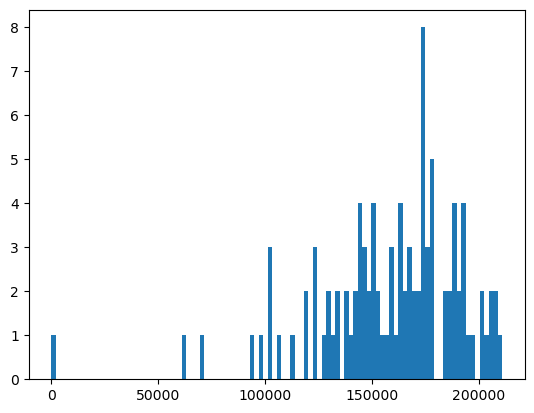

In [33]:
plt.hist(sum_channels,bins=100);

In [49]:
z= enumerate(ds.events())

In [51]:
z.length

AttributeError: 'enumerate' object has no attribute 'length'

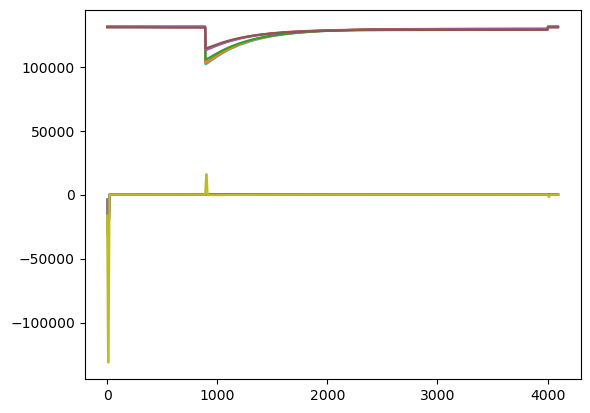

In [53]:
for i in range(0,16):
    plt.plot(data[i])